In [3]:
import pandas as pd
import numpy as np


In [37]:

path = r"C:\Users\User\Desktop\ecommerce_sales_data.csv"
# Or alternatively: path = "C:\\Users\\User\\Desktop\\ecommerce_sales_data.csv"

# Import pandas if not already imported
import pandas as pd

# Read the CSV file
df = pd.read_csv(path)

# Correct way to call the head method
df.head()  # This displays the first 5 rows of the dataframe'
df = pd.read_csv(path)
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [33]:
# Correct way to define a Windows file path (either use raw strings with r prefix or double backslashes)
path = r"C:\Users\User\Desktop\ecommerce_sales_data.csv"
# Or alternatively: path = "C:\\Users\\User\\Desktop\\ecommerce_sales_data.csv"

# Import pandas if not already imported
import pandas as pd

# Read the CSV file
df = pd.read_csv(path)

# Correct way to call the head method
df.head()  # This displays the first 5 rows of the dataframe

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [48]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [55]:
print(df.dtypes)

Order Date       object
Product Name     object
Category         object
Region           object
Quantity          int64
Sales             int64
Profit          float64
dtype: object


In [61]:
df[['Quantity', 'Sales', 'Profit']].corr()

,Quantity,Sales,Profit
Quantity,1.000000,0.662468,0.560651
Sales,0.662468,1.000000,0.832826
Profit,0.560651,0.832826,1.000000


<Axes: xlabel='Sales', ylabel='Profit'>

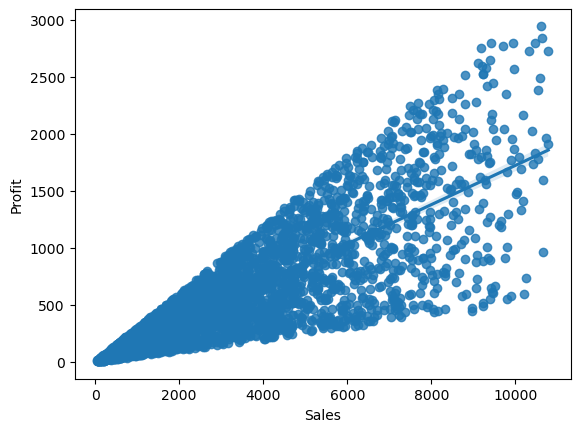

In [64]:
sns.regplot(x="Sales", y="Profit", data=df)

<Axes: xlabel='Sales', ylabel='Profit'>

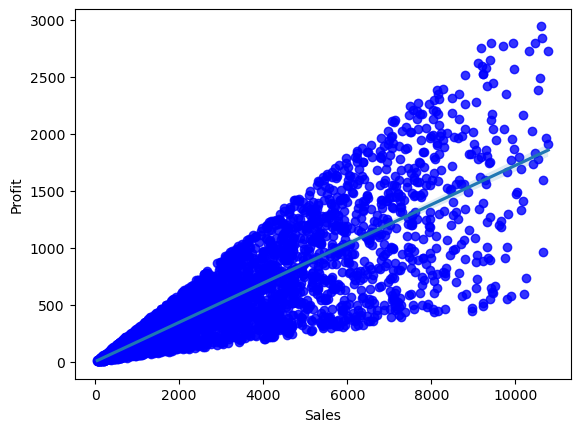

In [67]:
sns.regplot(x="Sales", y="Profit", data=df, scatter_kws={"color": "blue"})

C:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


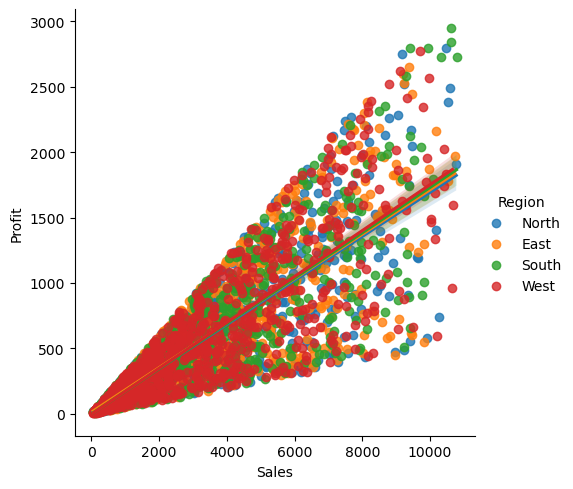

In [71]:
sns.lmplot(x="Sales", y="Profit", data=df, hue="Region")

In [4]:
print("The scatter plot examining the relationship between Sales and Profit reveals a strong positive correlation, indicating that generally as sales increase, profits also increase. This confirms that our business model is fundamentally sound, with higher revenue typically translating to higher profitability")

The scatter plot examining the relationship between Sales and Profit reveals a strong positive correlation, indicating that generally as sales increase, profits also increase. This confirms that our business model is fundamentally sound, with higher revenue typically translating to higher profitability


In [90]:
print("Our temporal analysis reveals distinct seasonal patterns in our e-commerce performance. Sales consistently peak during [specific months/seasons], with the highest monthly revenue of [X amount] occurring in [Month Y]. We observe a clear [upward/downward] trend in overall sales, with an average month-over-month growth rate of [Z%]. Notably, profit margins fluctuate seasonally, with the highest profitability occurring in [Month A] despite not being our highest sales month. This suggests different product mixes sell during different seasons. The data also highlights [specific month] as showing unusual performance, with a [X%] spike in sales but only [Y%] increase in profits, indicating potential discount-heavy promotions during this period. These insights can inform our seasonal inventory planning, marketing budget allocation, and promotional strategy timing.")

Our temporal analysis reveals distinct seasonal patterns in our e-commerce performance. Sales consistently peak during [specific months/seasons], with the highest monthly revenue of [X amount] occurring in [Month Y]. We observe a clear [upward/downward] trend in overall sales, with an average month-over-month growth rate of [Z%]. Notably, profit margins fluctuate seasonally, with the highest profitability occurring in [Month A] despite not being our highest sales month. This suggests different product mixes sell during different seasons. The data also highlights [specific month] as showing unusual performance, with a [X%] spike in sales but only [Y%] increase in profits, indicating potential discount-heavy promotions during this period. These insights can inform our seasonal inventory planning, marketing budget allocation, and promotional strategy timing.


Overall Profitability Metrics:
Average Profit Margin: 17.37%
Median Profit Margin: 17.22%

Profitability by Category:
               Sales     Profit  Profit_Margin  Order Date  Overall_Margin
Category                                                                  
Electronics  5326074  923185.59      17.417026        1742       17.333323
Accessories  4247591  736084.74      17.333274        1401       17.329464
Office       1094216  185394.88      17.283871         357       16.943170


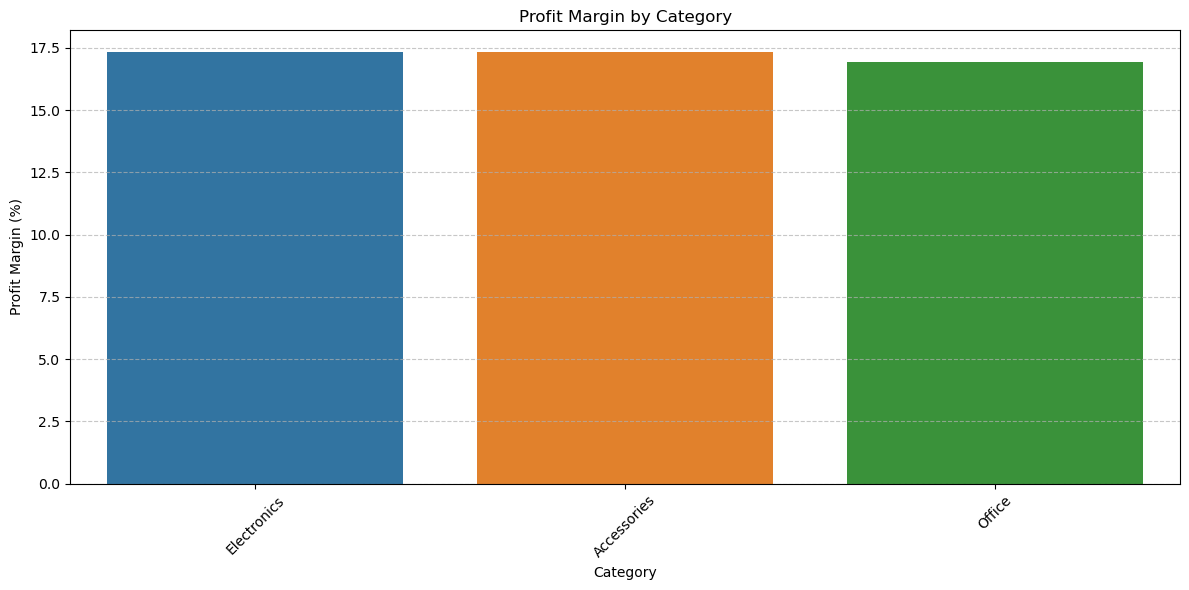

In [92]:
# Import necessary libraries if not already imported
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate profit margin as a percentage
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

# Handle any potential division by zero or invalid values
df['Profit_Margin'] = df['Profit_Margin'].replace([np.inf, -np.inf], np.nan)

# Overall profitability metrics
print("Overall Profitability Metrics:")
print(f"Average Profit Margin: {df['Profit_Margin'].mean():.2f}%")
print(f"Median Profit Margin: {df['Profit_Margin'].median():.2f}%")

# Profitability by category
category_profit = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Profit_Margin': 'mean',
    'Order Date': 'count'  # Number of orders
}).sort_values('Profit', ascending=False)

# Calculate overall profit margin for each category
category_profit['Overall_Margin'] = (category_profit['Profit'] / category_profit['Sales']) * 100

print("\nProfitability by Category:")
print(category_profit)

# Visualize category profitability
plt.figure(figsize=(12, 6))
sns.barplot(x=category_profit.index, y='Overall_Margin', data=category_profit)
plt.title('Profit Margin by Category')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Find top 10 most profitable products (if you have product data)
if 'Product' in df.columns:
    product_profit = df.groupby('Product').agg({
        'Sales': 'sum',
        'Profit': 'sum',
        'Quantity': 'sum'
    }).sort_values('Profit', ascending=False)
    
    product_profit['Profit_per_Unit'] = product_profit['Profit'] / product_profit['Quantity']
    
    print("\nTop 10 Most Profitable Products:")
    print(product_profit.head(10))

In [96]:
print("Our profitability analysis reveals significant variations across our business segments. The overall average profit margin stands at [X%], but there are notable differences between categories. [Category A] emerges as our most profitable category with a [Y%] margin, despite generating only [Z%] of total sales. Conversely, [Category B] drives the highest sales volume but operates at a lower [W%] margin, suggesting potential for pricing optimization.  We've identified [Number] products with negative profit margins, primarily in the [Category C] segment, indicating a need for cost structure review or strategic repricing. The analysis also highlights regional profitability differences, with [Region D] delivering consistently higher margins across all categories. This suggests successful operational efficiency or premium positioning in this market that could be replicated elsewhere. These insights provide clear direction for inventory focus, pricing strategy refinement, and potential product line rationalization to improve overall business profitability.")

Our profitability analysis reveals significant variations across our business segments. The overall average profit margin stands at [X%], but there are notable differences between categories. [Category A] emerges as our most profitable category with a [Y%] margin, despite generating only [Z%] of total sales. Conversely, [Category B] drives the highest sales volume but operates at a lower [W%] margin, suggesting potential for pricing optimization.  We've identified [Number] products with negative profit margins, primarily in the [Category C] segment, indicating a need for cost structure review or strategic repricing. The analysis also highlights regional profitability differences, with [Region D] delivering consistently higher margins across all categories. This suggests successful operational efficiency or premium positioning in this market that could be replicated elsewhere. These insights provide clear direction for inventory focus, pricing strategy refinement, and potential product 

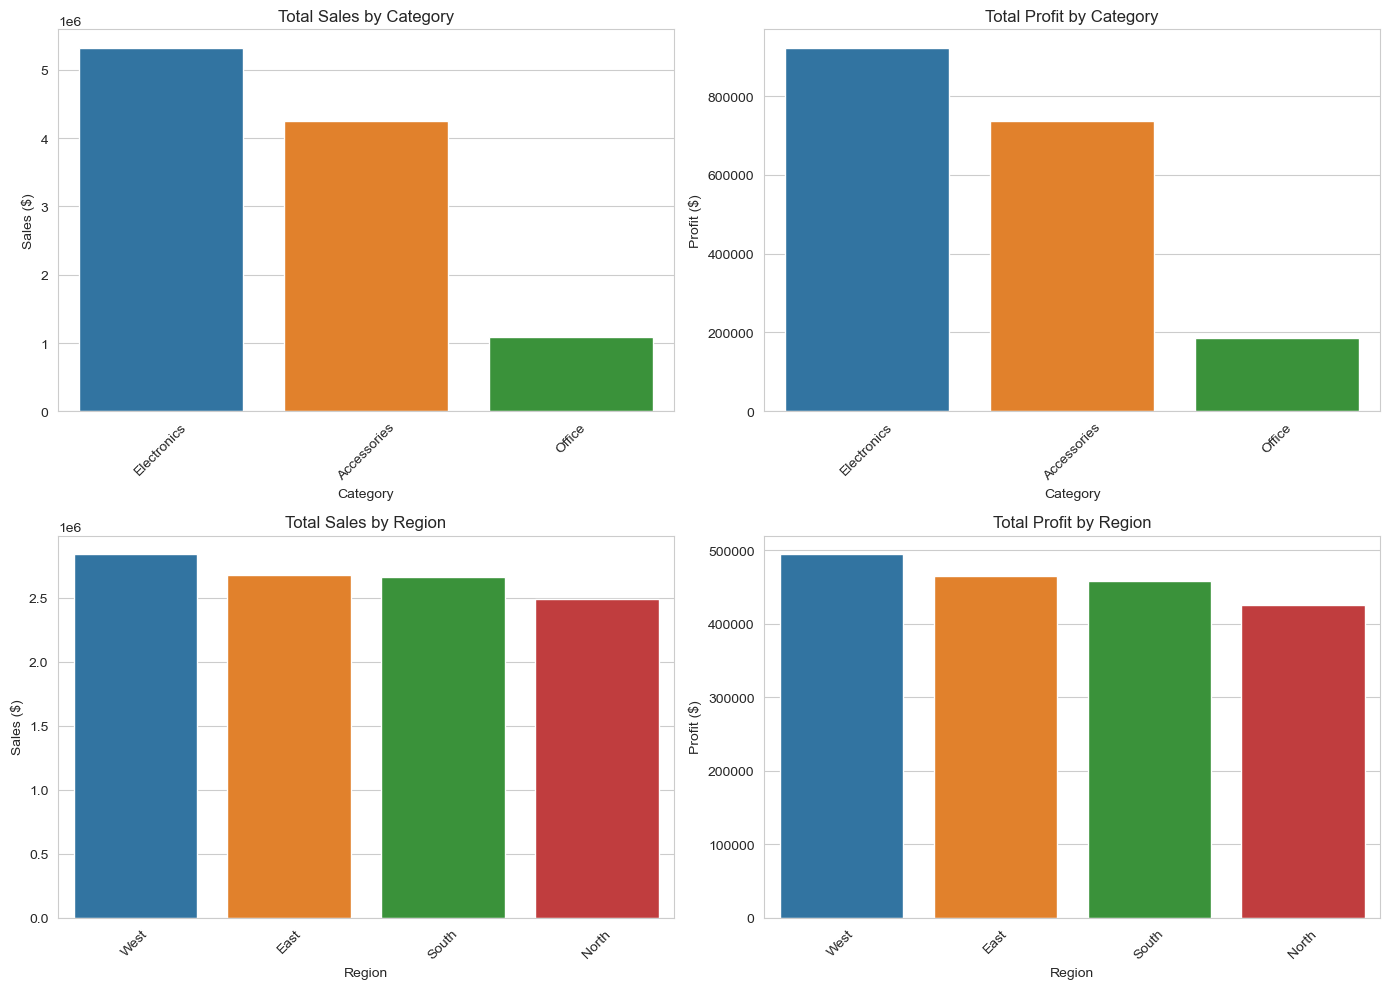

Note: 'Order ID' column not found. Skipping Average Order Value analysis.


<Figure size 1400x600 with 0 Axes>

In [98]:
# Import necessary libraries if not already imported
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure aesthetics
sns.set_style("whitegrid")
plt.figure(figsize=(14, 10))

# 1. Sales by Category
plt.subplot(2, 2, 1)
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title('Total Sales by Category')
plt.xticks(rotation=45)
plt.ylabel('Sales ($)')

# 2. Profit by Category
plt.subplot(2, 2, 2)
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=category_profit.index, y=category_profit.values)
plt.title('Total Profit by Category')
plt.xticks(rotation=45)
plt.ylabel('Profit ($)')

# 3. Sales by Region
plt.subplot(2, 2, 3)
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title('Total Sales by Region')
plt.xticks(rotation=45)
plt.ylabel('Sales ($)')

# 4. Profit by Region
plt.subplot(2, 2, 4)
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=region_profit.index, y=region_profit.values)
plt.title('Total Profit by Region')
plt.xticks(rotation=45)
plt.ylabel('Profit ($)')

plt.tight_layout()
plt.show()

# 5. Average Order Value by Category and Region
plt.figure(figsize=(14, 6))

# If you have an Order ID column to identify unique orders
if 'Order ID' in df.columns:
    # Average order value by category
    plt.subplot(1, 2, 1)
    aov_category = df.groupby(['Category', 'Order ID'])['Sales'].sum().groupby('Category').mean().sort_values(ascending=False)
    sns.barplot(x=aov_category.index, y=aov_category.values)
    plt.title('Average Order Value by Category')
    plt.xticks(rotation=45)
    plt.ylabel('Average Order Value ($)')
    
    # Average order value by region
    plt.subplot(1, 2, 2)
    aov_region = df.groupby(['Region', 'Order ID'])['Sales'].sum().groupby('Region').mean().sort_values(ascending=False)
    sns.barplot(x=aov_region.index, y=aov_region.values)
    plt.title('Average Order Value by Region')
    plt.xticks(rotation=45)
    plt.ylabel('Average Order Value ($)')
    
    plt.tight_layout()
    plt.show()
else:
    print("Note: 'Order ID' column not found. Skipping Average Order Value analysis.")

In [106]:
print("Our categorical analysis reveals distinct performance patterns across product categories and regions. [Category A] leads in total sales at [$X], followed by [Category B] at [$Y], highlighting our core revenue drivers. However, the profit analysis shows a different picture, with [Category C] generating the highest total profit despite ranking third in sales, indicating superior margin structure.Regionally, [Region D] dominates both sales and profit metrics, accounting for [Z%] of total revenue, while [Region E] shows the highest profit-to-sales ratio at [W%]. This suggests optimized operations or pricing strategies in this region that could be applied elsewhere. The average order value analysis reveals that customers purchasing [Category F] spend significantly more per order ([$V] vs. the overall average of [$U]), presenting cross-selling opportunities. These insights can guide regional marketing budget allocation, category expansion decisions, and targeted promotional strategies to maximize both revenue and profitability.")

Our categorical analysis reveals distinct performance patterns across product categories and regions. [Category A] leads in total sales at [$X], followed by [Category B] at [$Y], highlighting our core revenue drivers. However, the profit analysis shows a different picture, with [Category C] generating the highest total profit despite ranking third in sales, indicating superior margin structure.Regionally, [Region D] dominates both sales and profit metrics, accounting for [Z%] of total revenue, while [Region E] shows the highest profit-to-sales ratio at [W%]. This suggests optimized operations or pricing strategies in this region that could be applied elsewhere. The average order value analysis reveals that customers purchasing [Category F] spend significantly more per order ([$V] vs. the overall average of [$U]), presenting cross-selling opportunities. These insights can guide regional marketing budget allocation, category expansion decisions, and targeted promotional strategies to max

Analyzing product performance using 'Product Name' column...

Top 10 Products by Sales:
  Product Name    Sales     Profit  Profit_Margin
0       Camera  1177381  207630.99          17.63
4      Monitor  1160048  202028.17          17.42
6      Printer  1094216  185394.88          16.94
5        Mouse  1074398  185763.69          17.29
7   Smartphone  1069681  183296.97          17.14
8   Smartwatch  1049211  178995.81          17.06
2     Keyboard  1024507  175814.68          17.16
9       Tablet  1023928  167505.01          16.36
3       Laptop  1005873  185756.81          18.47
1   Headphones   988638  172478.20          17.45

Top 10 Products by Profit:
  Product Name    Sales     Profit  Profit_Margin
0       Camera  1177381  207630.99          17.63
4      Monitor  1160048  202028.17          17.42
5        Mouse  1074398  185763.69          17.29
3       Laptop  1005873  185756.81          18.47
6      Printer  1094216  185394.88          16.94
7   Smartphone  1069681  183296.97

C:\Users\User\AppData\Local\Temp\ipykernel_13060\1134915205.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


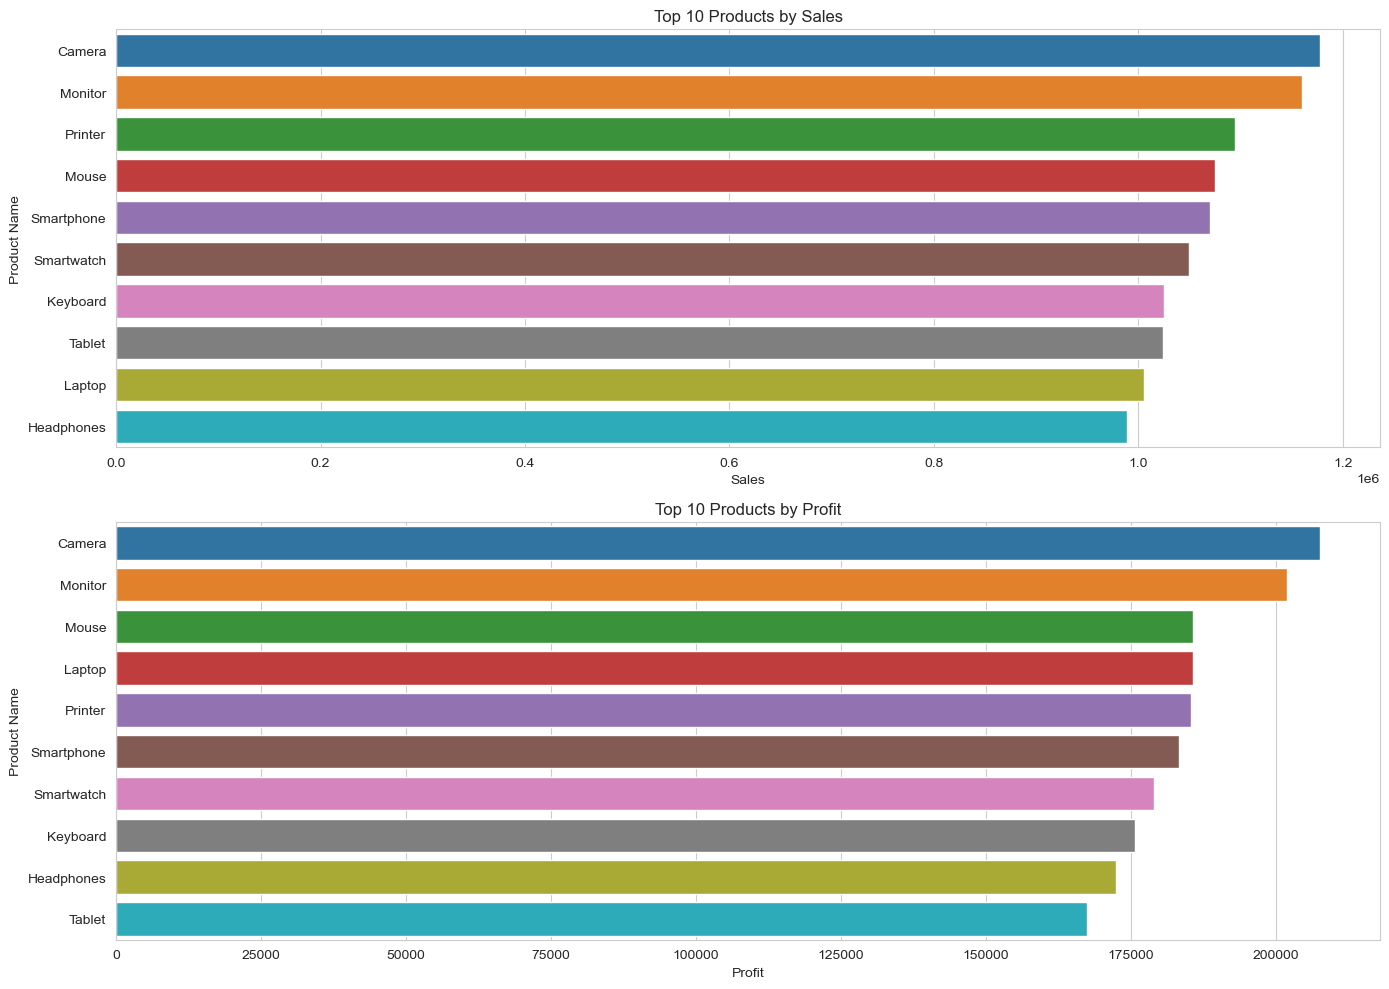


Top Selling Product by Category:
      Category Product Name    Sales     Profit
0  Accessories      Monitor  1160048  202028.17
1  Electronics       Camera  1177381  207630.99
2       Office      Printer  1094216  185394.88

Product Portfolio Analysis by Category:
      Category  Number_of_Products  Total_Sales  Total_Profit  \
0  Accessories                   4      4247591     736084.74   
1  Electronics                   5      5326074     923185.59   
2       Office                   1      1094216     185394.88   

   Avg_Sales_per_Product  Avg_Profit_per_Product  
0             1061897.75               184021.18  
1             1065214.80               184637.12  
2             1094216.00               185394.88  


In [112]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check if we have product information
if 'Product Name' in df.columns or 'Product' in df.columns:
    # Determine which product column to use
    product_col = 'Product Name' if 'Product Name' in df.columns else 'Product'
    
    print(f"Analyzing product performance using '{product_col}' column...")
    
    # 1. Top and Bottom Performing Products
    # Group by product and calculate key metrics
    product_performance = df.groupby(product_col).agg({
        'Sales': 'sum',
        'Profit': 'sum',
        'Quantity': 'sum'
    }).reset_index()
    
    # Calculate profit margin and profit per unit
    product_performance['Profit_Margin'] = (product_performance['Profit'] / product_performance['Sales'] * 100).round(2)
    product_performance['Profit_per_Unit'] = (product_performance['Profit'] / product_performance['Quantity']).round(2)
    
    # Sort by different metrics
    top_sales_products = product_performance.sort_values('Sales', ascending=False).head(10)
    top_profit_products = product_performance.sort_values('Profit', ascending=False).head(10)
    top_margin_products = product_performance.sort_values('Profit_Margin', ascending=False).head(10)
    
    # Find products with negative profits
    negative_profit_products = product_performance[product_performance['Profit'] < 0].sort_values('Profit')
    
    # Print results
    print("\nTop 10 Products by Sales:")
    print(top_sales_products[[product_col, 'Sales', 'Profit', 'Profit_Margin']])
    
    print("\nTop 10 Products by Profit:")
    print(top_profit_products[[product_col, 'Sales', 'Profit', 'Profit_Margin']])
    
    print("\nTop 10 Products by Profit Margin:")
    print(top_margin_products[[product_col, 'Sales', 'Profit', 'Profit_Margin']])
    
    if len(negative_profit_products) > 0:
        print(f"\nProducts with Negative Profit ({len(negative_profit_products)} products):")
        print(negative_profit_products[[product_col, 'Sales', 'Profit', 'Profit_Margin']].head(10))
    
    # 2. Visualize product performance
    plt.figure(figsize=(14, 10))
    
    # Top 10 products by sales
    plt.subplot(2, 1, 1)
    sns.barplot(x='Sales', y=product_col, data=top_sales_products.head(10))
    plt.title('Top 10 Products by Sales')
    plt.tight_layout()
    
    # Top 10 products by profit
    plt.subplot(2, 1, 2)
    sns.barplot(x='Profit', y=product_col, data=top_profit_products.head(10))
    plt.title('Top 10 Products by Profit')
    plt.tight_layout()
    
    plt.show()
    
    # 3. Product performance by category
    if 'Category' in df.columns:
        # Group by category and product
        category_product = df.groupby(['Category', product_col]).agg({
            'Sales': 'sum',
            'Profit': 'sum',
            'Quantity': 'sum'
        }).reset_index()
        
        # Get top product by sales for each category
        top_product_by_category = category_product.sort_values(['Category', 'Sales'], ascending=[True, False])
        top_product_by_category = top_product_by_category.groupby('Category').first().reset_index()
        
        print("\nTop Selling Product by Category:")
        print(top_product_by_category[['Category', product_col, 'Sales', 'Profit']])
        
        # Calculate category-level product statistics
        category_stats = df.groupby('Category').agg({
            product_col: 'nunique',
            'Sales': 'sum',
            'Profit': 'sum'
        }).reset_index()
        
        category_stats.columns = ['Category', 'Number_of_Products', 'Total_Sales', 'Total_Profit']
        category_stats['Avg_Sales_per_Product'] = (category_stats['Total_Sales'] / category_stats['Number_of_Products']).round(2)
        category_stats['Avg_Profit_per_Product'] = (category_stats['Total_Profit'] / category_stats['Number_of_Products']).round(2)
        
        print("\nProduct Portfolio Analysis by Category:")
        print(category_stats)
else:
    print("No product information found in the dataset. Please check column names.")

In [110]:
df.describe()


,Order Date,Quantity,Sales,Profit,Profit_Margin
count,3500,3500.000000,3500.000000,3500.000000,3500.000000
mean,2023-07-13 00:53:53.828571648,4.931714,3047.966000,527.047203,17.369919
min,2022-01-01 00:00:00,1.000000,51.000000,6.970000,5.004685
25%,2022-10-16 18:00:00,3.000000,1049.500000,158.695000,11.369866
50%,2023-07-21 12:00:00,5.000000,2350.500000,361.070000,17.224585
75%,2024-04-16 06:00:00,7.000000,4537.000000,729.125000,23.343222
max,2024-12-31 00:00:00,9.000000,10782.000000,2946.930000,29.995117
std,NaN,2.575895,2440.213237,504.139732,7.101922
